# COVID-19 Economic Recovery Analysis

## 1. Problem Definition

This project aims to analyse how different countries recovered economically after the COVID-19 pandemic using GDP data. The objective is to compare recovery speed across countries and understand differences between economies.

## 2. Data Source

The dataset is obtained from the World Bank and is based on GDP (current US$). It includes selected countries across different regions and income levels, covering the years 2018 to 2023.

This time period allows comparison before, during, and after the COVID-19 pandemic.

## 3. Data Loading

In [1]:
import pandas as pd

# Show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Load dataset
df = pd.read_csv("data/world_bank_gdp.csv")

# Display full dataset
df

,Country Name,2018,2019,2020,2021,2022,2023
0,Argentina,5.248200e+11,4.477550e+11,3.857410e+11,4.865640e+11,6.339940e+11,6.494620e+11
1,Australia,1.433140e+12,1.398350e+12,1.333340e+12,1.560620e+12,1.695630e+12,1.734450e+12
2,Brazil,1.916930e+12,1.873290e+12,1.476110e+12,1.670650e+12,1.951920e+12,2.191130e+12
3,Canada,1.725330e+12,1.743730e+12,1.655680e+12,2.022380e+12,2.190410e+12,2.173340e+12
4,China,1.414780e+13,1.456020e+13,1.499640e+13,1.820170e+13,1.831680e+13,1.827040e+13
5,Germany,4.055430e+12,3.959890e+12,3.941400e+12,4.355250e+12,4.201020e+12,4.562210e+12
6,Spain,1.431640e+12,1.403500e+12,1.289780e+12,1.461240e+12,1.448850e+12,1.619480e+12
7,France,2.781580e+12,2.722790e+12,2.647930e+12,2.966430e+12,2.794790e+12,3.056250e+12
8,United Kingdom,2.897030e+12,2.875710e+12,2.724000e+12,3.194560e+12,3.181240e+12,3.420800e+12
9,Indonesia,1.042270e+12,1.119100e+12,1.059050e+12,1.186510e+12,1.319100e+12,1.371170e+12


## 4. Data Cleaning

In [2]:
# Set country as index
df.set_index("Country Name", inplace=True)

# Convert GDP to trillion USD
df = df / 1e12

# Display cleaned data
df

,2018,2019,2020,2021,2022,2023
Country Name,,,,,,
Argentina,0.524820,0.447755,0.385741,0.486564,0.633994,0.649462
Australia,1.433140,1.398350,1.333340,1.560620,1.695630,1.734450
Brazil,1.916930,1.873290,1.476110,1.670650,1.951920,2.191130
Canada,1.725330,1.743730,1.655680,2.022380,2.190410,2.173340
China,14.147800,14.560200,14.996400,18.201700,18.316800,18.270400
Germany,4.055430,3.959890,3.941400,4.355250,4.201020,4.562210
Spain,1.431640,1.403500,1.289780,1.461240,1.448850,1.619480
France,2.781580,2.722790,2.647930,2.966430,2.794790,3.056250
United Kingdom,2.897030,2.875710,2.724000,3.194560,3.181240,3.420800


GDP values are converted into trillion USD for better readability.

## 5. Analysis

### Calculate Growth Rate

In [3]:
# Calculate GDP growth rate (2019–2023)
growth_rate = (df["2023"] - df["2019"]) / df["2019"] * 100

# Display growth rate
growth_rate

Country Name
Argentina         45.048520
Australia         24.035470
Brazil            16.966941
Canada            24.637415
China             25.481793
Germany           15.210524
Spain             15.388671
France            12.246997
United Kingdom    18.954971
Indonesia         22.524350
India             28.314190
Japan            -17.679206
Korea, Rep.        5.353930
Mexico            37.896343
Nigeria          -27.061746
Saudi Arabia      37.090079
United States     27.646976
South Africa      -2.026302
dtype: float64

### Ranking Countries by Growth Rate

In [4]:
# Sort countries by growth rate
growth_rate = growth_rate.sort_values(ascending=False)

# Create ranking
ranking = growth_rate.rank(ascending=False)

# Combine into a table
result = pd.DataFrame({
    "Growth Rate (%)": growth_rate,
    "Rank": ranking
})

# Display result
result

,Growth Rate (%),Rank
Country Name,,
Argentina,45.048520,1.0
Mexico,37.896343,2.0
Saudi Arabia,37.090079,3.0
India,28.314190,4.0
United States,27.646976,5.0
China,25.481793,6.0
Canada,24.637415,7.0
Australia,24.035470,8.0
Indonesia,22.524350,9.0


Countries are ranked by GDP growth rate to identify which economies recovered faster after COVID-19.

## 6. Visualisation
### GDP Growth Rate Comparison (Bar Chart)

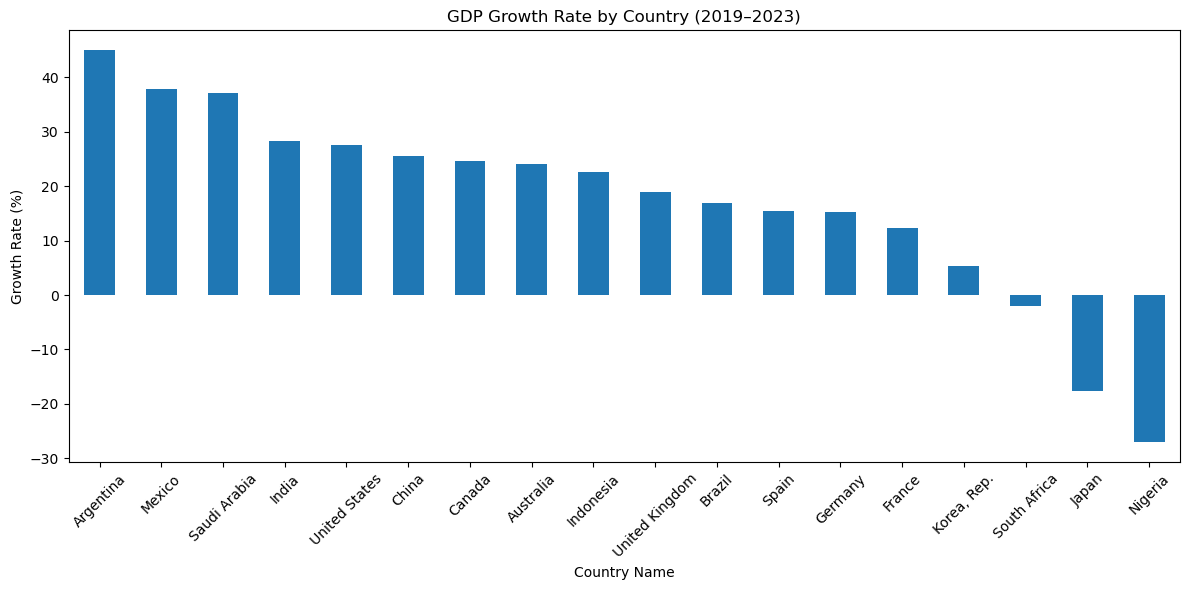

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

growth_rate.plot(kind="bar")

plt.title("GDP Growth Rate by Country (2019–2023)")
plt.ylabel("Growth Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("figures/gdp_growth_rate.png")

plt.show()

The bar chart compares GDP growth rates across countries.

### GDP Trend Over Time (Line Chart)

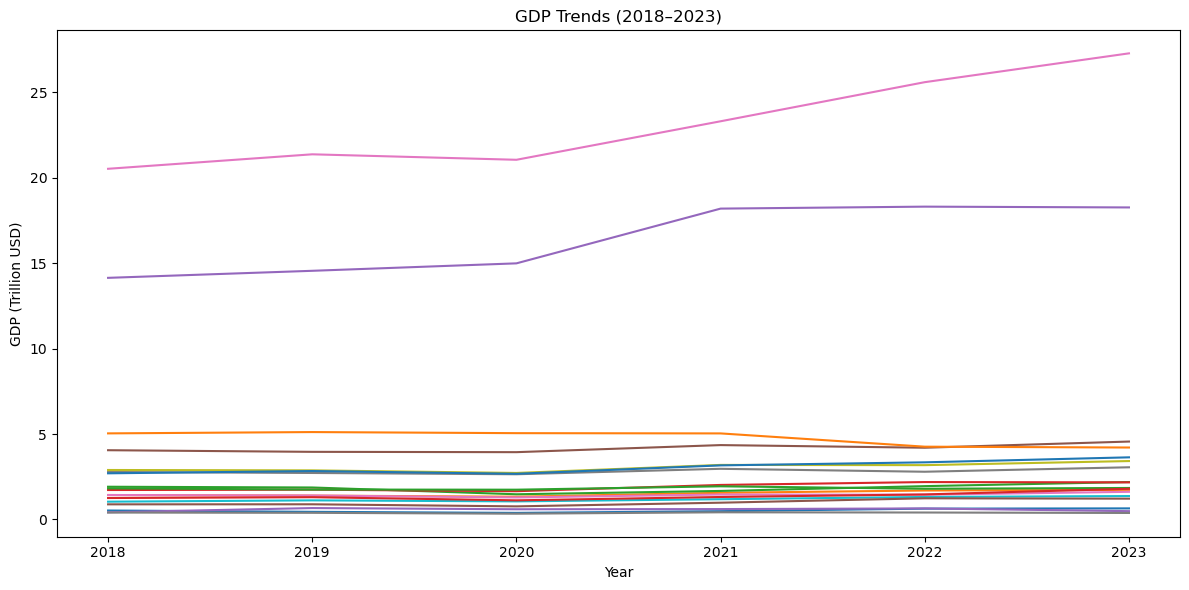

In [6]:
plt.figure(figsize=(12,6))

for country in df.index:
    plt.plot(df.columns, df.loc[country])

plt.title("GDP Trends (2018–2023)")
plt.xlabel("Year")
plt.ylabel("GDP (Trillion USD)")

plt.tight_layout()
plt.savefig("figures/gdp_trend.png")

plt.show()

The line chart shows GDP changes between 2018 and 2023 for each country.

### Key Insights

- All selected countries show recovery after COVID-19, but the speed differs across countries.
- Some countries achieve higher growth rates, while others show more stable but slower growth.
- Larger economies tend to have lower percentage growth due to their higher starting base.
- The data shows a clear dip around 2020 followed by recovery, reflecting the impact of the pandemic.

## 7. Conclusion

This project analysed economic recovery after COVID-19 using GDP data from multiple countries and years. The results show that while all countries experienced recovery, the pace varies significantly.

By including more countries and a longer time period, the analysis provides a clearer comparison of recovery patterns. However, as the analysis is based on nominal GDP, it mainly reflects changes in economic size and can be considered alongside other indicators for a more complete understanding.